# Aedes-AI GRU Model with Mean Temperature as Input


This code trains and tests a GRU model that estimates Aedes aegypti abundance from the following time series.

* Daily mean temperature (C)
* Daily precipitation (cm)
* Daily relative humidity

The GRU is trained to reproduce the results of MoLS.

## Train the Aedes-AI base model

We are now ready to train the model. Additional definitions are imported from `training.py` in the utils directory.

The resulting model will be added to the local utils/model_files directory.


In [1]:
import sys, json, os, json
sys.path.append('../')
import tensorflow as tf
import tensorflow.keras.backend as K
import utils.models as models
import utils.training as training_utils

import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler
import pickle, importlib

import utils.predictions as predictions

# Opening config file
f = open('../fpaths_config.json')
paths = json.load(f)

weather_path = paths["weather_data"]
mols_path = paths["raw_mols"]
nn_preds_path = paths["nn_abundance_predictions"]
model_files_path = paths["model_files"]

In [2]:
fpath='{}/gru_avg_temp_config.json'.format(model_files_path)

with open(fpath, 'r+') as fp:
  data = json.load(fp)
  data['data']['data_shape']=[90,3]
  data['files']['model']='{}/gru_avg_temp.h5'.format(model_files_path)
  data['files']['training']='{}/train_avg_data.pd'.format(model_files_path)
  data['files']['validation']='{}/val_avg_data.pd'.format(model_files_path)
  data['files']['testing']='{}/test_avg_data.pd'.format(model_files_path)
with open(fpath, 'w') as fp:
  json.dump(data,fp)

In [ ]:
#os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

gpus = tf.config.list_physical_devices('GPU')
if gpus:
  # Restrict TensorFlow to only allocate 3GB of memory on the first GPU
  try:
    tf.config.experimental.set_virtual_device_configuration(
        gpus[0],
        [tf.config.experimental.VirtualDeviceConfiguration(memory_limit=2*1024)])
    logical_gpus = tf.config.experimental.list_logical_devices('GPU')
    print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
  except RuntimeError as e:
    # Virtual devices must be set before GPUs have been initialized
    print(e)

np.random.seed(14)

# load the model as necessary
with open("{}/gru_avg_temp_config.json".format(model_files_path)) as fp:
  config=json.load(fp)

model_file = os.path.expanduser(config['files']['model'])
if os.path.exists(model_file):
  model = tf.keras.models.load_model(model_file, custom_objects = {'r2_keras': predictions.r2_keras})
  print(model_file + ' already exists')
else:
  model = getattr(models, config['model'])(config['data']['data_shape'])
     
  summer_cities = set(pd.read_csv(os.path.expanduser('{}/hi_locs.csv'.format(model_files_path)), squeeze=True, index_col=0))
  winter_cities = {"Dane,Wisconsin", "Milwaukee,Wisconsin", "New Haven,Connecticut", "Bronx,New York", "Kings,New York",
                     "Monmouth,New Jersey", "Mono,California", "Monterey,California", "Morris,New Jersey", "Napa,California",
                     "Nassau,New York", "New Hanover,North Carolina", "New River,Arizona", "Okaloosa,Florida", "Orange,California",
                     "Oro Valley,Arizona", "Prescott,Arizona", "Rio Rico,Arizona", "Rockland,New York", "Sacramento,California"}

  # get the data
  training = pd.read_pickle(os.path.expanduser(config['files']['training']))
  validation = pd.read_pickle(os.path.expanduser(config['files']['validation']))
  testing = pd.read_pickle(os.path.expanduser(config['files']['testing']))
  training, scaler = training_utils.format_data(training, config['data']['data_shape'], config['data']['samples_per_city'],
                                   scaler=MinMaxScaler(), fit_scaler=True,
                                   summer_samples=config['data']['summer_samples'],
                                   winter_samples=config['data']['winter_samples'],
                                   summer_cities=summer_cities,
                                   winter_cities=winter_cities)
  
  with open('{}/avg_scaler.pkl'.format(model_files_path), 'wb') as f:
    pickle.dump(scaler, f)
    
  validation = training_utils.format_data(validation, config['data']['data_shape'], config['data']['samples_per_city'],
                             scaler=scaler)
  testing = training_utils.format_data(testing, config['data']['data_shape'], config['data']['samples_per_city'],
                          scaler=scaler)
   
  X_train, y_train = training_utils.split_and_shuffle(training)
  X_val, y_val = training_utils.split_and_shuffle(validation)
  X_test, y_test = training_utils.split_and_shuffle(testing)


  model.compile(optimizer = getattr(tf.keras.optimizers, config['compile']['optimizer'])(lr = config['compile']['learning_rate']),
                      loss = config['compile']['loss'], metrics = [predictions.r2_keras])
  history = model.fit(X_train, y_train, validation_data = (X_val, y_val), **config['fit'],
                  callbacks = [tf.keras.callbacks.TensorBoard(), tf.keras.callbacks.EarlyStopping(patience = 15, restore_best_weights = True)])
  model.save(model_file, save_format = 'h5')

C:\Users\Adrienne\AppData\Local\Temp\ipykernel_7776\2805443259.py:29: FutureWarning: The squeeze argument has been deprecated and will be removed in a future version. Append .squeeze("columns") to the call to squeeze.


  summer_cities = set(pd.read_csv(os.path.expanduser('{}/hi_locs.csv'.format(model_files_path)), squeeze=True, index_col=0))


(95755, 90, 4)
(62709, 90, 4)
(25187, 90, 4)
Epoch 1/100


c:\Users\Adrienne\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


1497/1497 [==============================] - 113s 73ms/step - loss: 0.0042 - r2_keras: 0.7765 - val_loss: 0.0029 - val_r2_keras: 0.8693
Epoch 2/100
1497/1497 [==============================] - 107s 72ms/step - loss: 0.0030 - r2_keras: 0.8605 - val_loss: 0.0024 - val_r2_keras: 0.8903
Epoch 3/100
1212/1497 [=======================>......] - ETA: 17s - loss: 0.0025 - r2_keras: 0.8800

In [32]:
importlib.reload(predictions)

with open("{}/gru_avg_temp_config.json".format(model_files_path)) as fp:
  config=json.load(fp)

data_shape = config['data']['data_shape']
test_data = pd.read_pickle(config['files']['testing'])
model_fil = config['files']['model']

model = tf.keras.models.load_model(model_fil, custom_objects = {'r2_keras': predictions.r2_keras})

with open ('{}/avg_scaler.pkl'.format(model_files_path), 'rb') as f:
    loaded_scaler = pickle.load(f)
    

results = predictions.gen_preds(model, test_data, data_shape, loaded_scaler, fit_scaler=False)
results = pd.DataFrame(results, columns=['Location', 'Year', 'Month', 'Day', 'MoLS', 'Neural Network'])

3145/3145 [==============================] - 51s 16ms/step


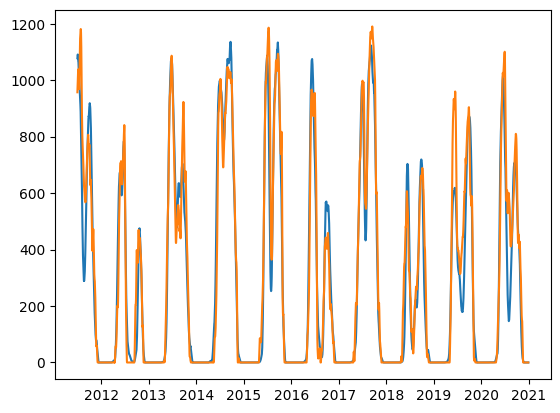

In [33]:
import matplotlib.pyplot as plt
results['Datetime'] = pd.to_datetime(results[['Year', 'Month', 'Day']])
avondale = results[results.Location.str.contains('Avondale')]

plt.figure()
plt.plot(avondale.Datetime, avondale.MoLS, color='tab:blue')
plt.plot(avondale.Datetime, avondale['Neural Network'], color='tab:orange')
#plt.xlim([results.Datetime.iloc[0], results.Datetime.iloc[1000]])
plt.show()